# Tutorial 1: Image segmentation using thresholding methods

Welcome to the image segmentation portion of the workshop! You will first get started with exploring thresholding methods.

This tutorial assumes no prior AI/ML background. We explain each idea before coding it.

## What you will learn

1. What threshold-based segmentation means
2. How Otsu, Niblack, and Sauvola thresholding differ
3. How to process multiple XCT slices as a stack
4. How to save segmented (binary) outputs

## Credits

These code chunks were initially developed by Aramy Truong and Hasitha Wijesuriya, which were refined by GitHub Co-pilot on VS Code.

## Points of contact

- Aramy Truong (Computational Scientist): aramy.truong@pnnl.gov
- Hasitha Wijesuriya (Post Doctorate RA C): hasitha.wijesuriya@pnnl.gov

Before we get started, let us review the core ideas of image segmentation and how it can transform the way we analyze images!

## What is image segmentation?

- Image segmentation is a fundamental task in computer vision that involves partitioning an image into meaningful regions or segments
- It is crucial for various applications, including object recognition, medical imaging, autonomous driving, and scene understanding

Here is how a segmented image looks like. Note that there are two classes (coin and background) and so, it is binary image segmentation.

<div style="text-align: center; margin-top: 20px"><img src="notebook_img/binary_img_seg.png" width="600" alt="Binary Image Segmentation"></div>

## Why is it important in soil science?

- Image segmentation allows researchers to identify and quantify different soil components, such as organic matter, minerals, and pore space
    - This information is essential for studying soil health, fertility, and water retention capabilities
- Image segmentation can help in monitoring soil erosion, assessing land degradation, and optimizing agricultural practices 
    - By providing insights into soil composition and structure

## Challenges in image segmentation

Despite its importance, image segmentation faces several challenges, including:

1. **Variability in Image Quality**: Images can vary in quality due to factors like contrast, noise, and resolution
2. **Complexity of Scenes**: Real-world images often contain complex scenes with multiple objects and varying backgrounds
3. **Computational Complexity**: Some segmentation techniques can be computationally intensive and require significant resources for training
4. **Lack of Annotated Data**: Obtaining annotated data can be time-consuming and expensive, especially in specialized domains like soil science
5. **Generalization**: Segmentation models may struggle to generalize well to new images or different domains, leading to reduced performance 

## What is thresholding?

Thresholding methods converts raw images into binary masks based on a specific threshold value.

Every pixel is labeled as either:

- **Foreground** — pixels brighter than the threshold
- **Background** — pixels darker than the threshold

The key question is: *how do you pick the right threshold?* Different thresholding methods answer this differently:

| Method | How it picks the threshold |
|--------|---------------------------|
| **Otsu** | Finds the value that best separates two groups across the whole image |
| **Niblack** | Uses a small local window around each pixel, accounting for local brightness variations |
| **Sauvola** | Similar to Niblack but more robust to uneven lighting and noise |

In this tutorial, we use thresholding methods for segmenting XCT images of soil systems.

## Step 0 - Imports and setup

We import the packages used throughout the notebook ahead of time so that we can use specific functions for thresholding. 

In [ ]:
!git clone https://github.com/EMSL-MONet/Connect_and_Learn_2026 # Clone the repository to your colab runtiem environemnt

In [1]:
# ----------------------------
# Basic imports
# ----------------------------

import os                        # Built-in: navigate file paths and directories
import copy                      # Built-in: make deep copies of arrays/objects without modifying the original

import numpy as np               # NumPy: fast multi-dimensional array math (used for pixel arrays)
import matplotlib.pyplot as plt  # Matplotlib (pyplot): create plots and display images inline
import matplotlib.image as mpimg # Matplotlib (image): read image files directly into NumPy arrays

from PIL import Image            # Pillow: open, manipulate, and save image files (PNG, TIFF, etc.)

# scikit-image thresholding algorithms:
#   threshold_otsu    -- global threshold that minimizes intra-class variance
#   threshold_niblack -- local threshold using per-window mean and standard deviation
#   threshold_sauvola -- improved local threshold, more robust to uneven lighting
from skimage.filters import threshold_otsu, threshold_niblack, threshold_sauvola
from ipywidgets import interact, IntSlider # ipywidgets: create interactive sliders and controls for Jupyter notebooks

## Step 1 - Defining helper functions

Before we start processing images, we define tiny functions to help other functions run. These are called helper functions.

In [6]:
# ----------------------------
# Helper functions
# ----------------------------

def to_grayscale(arr):
    """Convert an image array to 2D grayscale if it has colour channels

    Many XCT images are stored as RGB or RGBA even though the data is grayscale

    This function collapses the colour channels by averaging them, giving a single intensity value per pixel
    """
    if arr.ndim == 3:
        # Array has shape (H, W, C) -- average the first 3 channels (R, G, B)
        # The [..., :3] slice drops the alpha channel if one exists
        return np.mean(arr[..., :3], axis=2)
    # Array is already 2D (H, W) -- return as-is
    return arr



## Step 2 - Configuration

We keep all key parameters in one place so you can change the inputs of the code at one place.

Go through the comments to identify the inputs.

In [ ]:
# ----------------------------
# Configuration
# ----------------------------
# Change the values below to match your own data and preferences
# Keeping all settings here makes it easy to experiment without hunting through the whole notebook

# Path to the folder that contains your XCT image slices
IMAGE_DIR = "./Connect_and_Learn_2026/XCT/data/raw_img"

# How many slices to include in the stack analysis (keep small to run quickly)
MAX_SLICES_TO_LOAD = 10

# Only files with these extensions will be picked up by the loader
VALID_EXTS = (".tif", ".tiff", ".png")

# --- Niblack local-threshold parameters ---
# NIBLACK_WINDOW: size (in pixels) of the square neighbourhood around each pixel
#   Larger values = smoother, more global; smaller values = finer, more local
NIBLACK_WINDOW = 101
# NIBLACK_K: weight applied to the local standard deviation
#   Higher k keeps only very bright areas as foreground
NIBLACK_K = 0.2

# --- Sauvola local-threshold parameter ---
# Same window-size concept as Niblack; Sauvola also normalises by dynamic range
SAUVOLA_WINDOW = 101


## Step 3 - Load one XCT slice and inspect intensity

Before segmentation, we inspect one grayscale slice and its histogram.

Why this matters - Thresholding splits pixels by intensity, so the histogram helps us predict whether a clean split is likely.

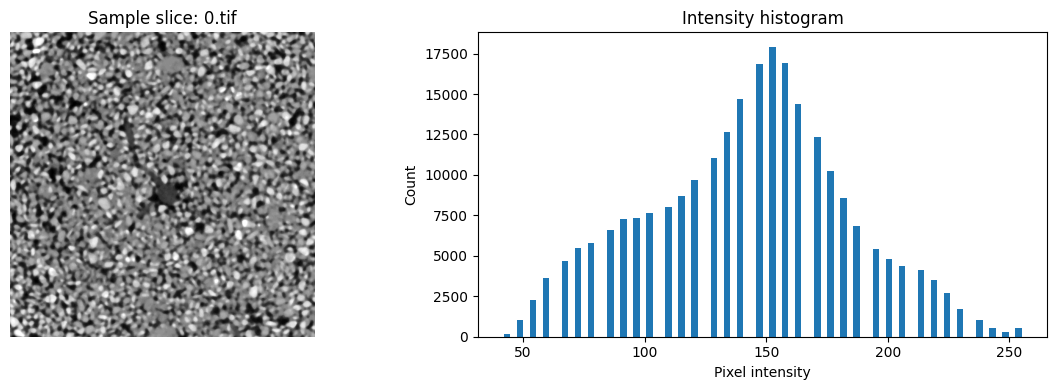

In [7]:
# ----------------------------
# Load one sample image
# ----------------------------

# List all files in IMAGE_DIR, keep only those with valid extensions, and sort alphabetically so slice order is consistent across runs
image_files = sorted([f for f in os.listdir(IMAGE_DIR) if f.lower().endswith(VALID_EXTS)])

# Stop early with a clear message if the folder is empty or path is wrong
assert len(image_files) > 0, "No images found in IMAGE_DIR"

# Pick the first file as a representative sample for inspection
sample_file = image_files[0]
sample_path = os.path.join(IMAGE_DIR, sample_file)  # Build the full file path

# Read the image from disk and convert to float32 grayscale (values 0–255)
sample_img = mpimg.imread(sample_path)

# --- Visualisation: side-by-side image + histogram ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # Two plots in one row

# Left panel: the raw grayscale slice.
ax[0].imshow(sample_img, cmap="gray")           # Display as grayscale
ax[0].set_title(f"Sample slice: {sample_file}")
ax[0].axis("off")                               # Hide axes ticks/labels for cleaner view

# Right panel: pixel intensity histogram
# ravel() flattens the 2D array to 1D so hist() can count all pixel values
# bins=80 controls the resolution of the histogram buckets
ax[1].hist(sample_img.ravel(), bins=80)
ax[1].set_title("Intensity histogram")
ax[1].set_xlabel("Pixel intensity")  # X-axis = brightness value
ax[1].set_ylabel("Count")            # Y-axis = number of pixels at that brightness

plt.tight_layout()  # Prevent panels from overlapping
plt.show()


Then let's see how well we can segment the above image manually.

In [11]:
def update_threshold(thresh_val):
    '''
    Update the binary image based on the threshold value and display both original and binary images.
    Parameters:
    thresh_val (int): The threshold value to convert the grayscale image to binary.
    '''
    binary_img = sample_img > thresh_val
    plt.figure(figsize=(18, 6))
    
    
    plt.subplot(1, 3, 1)
    plt.imshow(sample_img, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')
    plt.subplot(1, 3, 2)
    plt.hist(sample_img.ravel(), bins=80)
    plt.axvline(thresh_val, color='r', linestyle='--', label=f'Threshold: {thresh_val}')
    plt.title('Image Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Count')
    plt.subplot(1, 3, 3)
    plt.imshow(binary_img, cmap='gray')
    plt.title(f'Binary Image (Threshold: {thresh_val})')
    plt.axis('off')
    

    plt.tight_layout()
    plt.show()


interact(update_threshold, thresh_val=IntSlider(min=0, max=255, step=1, value=127, description='Threshold Value:'));

interactive(children=(IntSlider(value=127, description='Threshold Value:', max=255), Output()), _dom_classes=(…

## Step 4 - Compare thresholding methods (Otsu, Niblack, Sauvola)

We compare thresholding results from 3 different methods

- **Otsu**: one global threshold for the whole image
- **Niblack**: local threshold based on local mean and variance
- **Sauvola**: local threshold, often more robust to uneven contrast

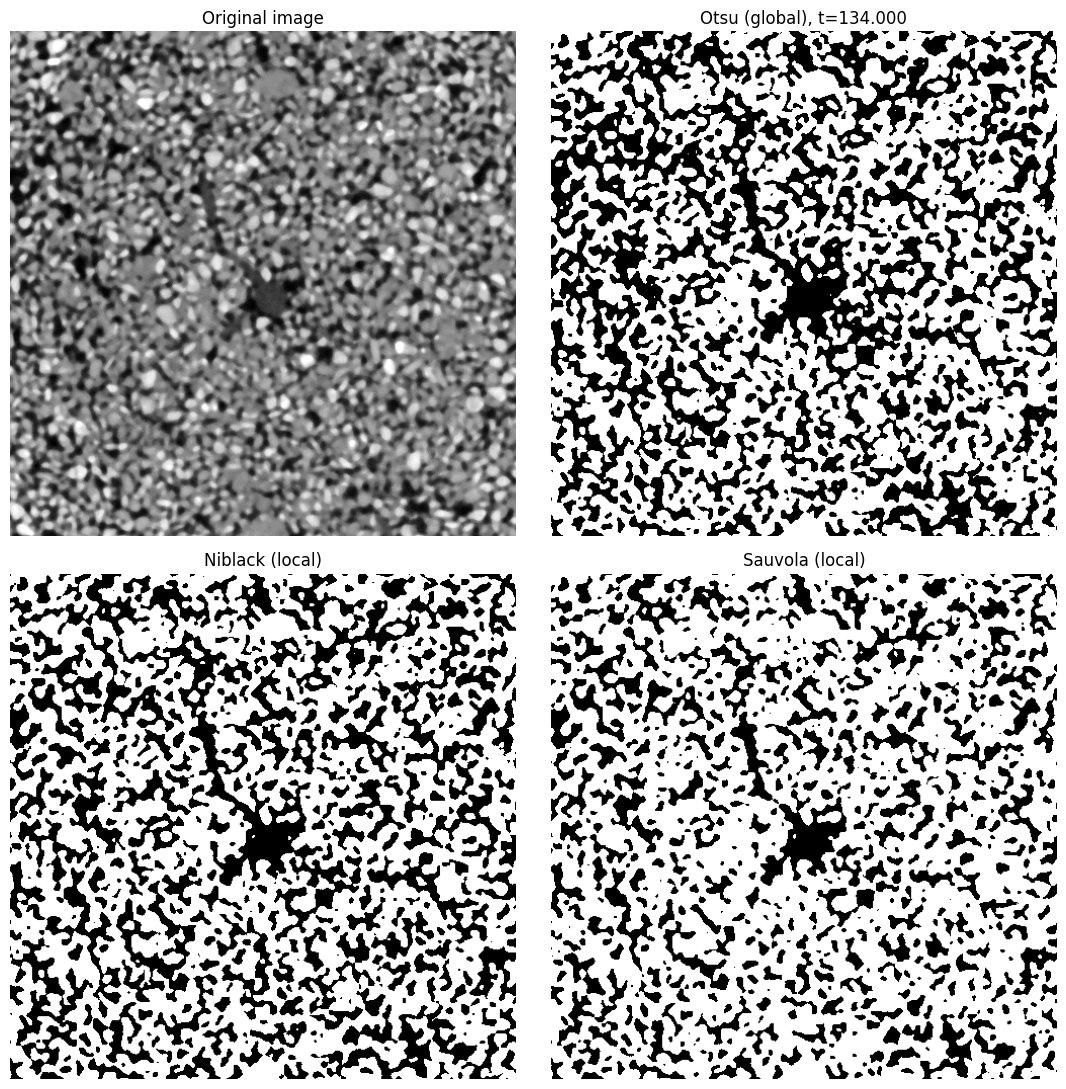

In [12]:
# ----------------------------
# Threshold comparison on one slice
# ----------------------------

# --- Step A: Compute thresholds ---

# Otsu: analyses the whole image histogram and returns a single number 
thresh_otsu = threshold_otsu(sample_img)

# Niblack: returns an array the same size as the image
# Each pixel gets its own local threshold based on the mean and std deviation of its surrounding window (size = NIBLACK_WINDOW x NIBLACK_WINDOW)
thresh_niblack = threshold_niblack(sample_img, window_size=NIBLACK_WINDOW, k=NIBLACK_K)

# Sauvola: similar to Niblack but uses a normalised form that is less sensitive
# to large background intensity swings.
thresh_sauvola = threshold_sauvola(sample_img, window_size=SAUVOLA_WINDOW)

# --- Step B: Apply thresholds to create binary masks ---
# Each comparison ( > threshold ) produces a boolean array:
#   True  (white) = pixel intensity above threshold → foreground
#   False (black) = pixel intensity below threshold → background

binary_otsu    = sample_img > thresh_otsu     # Simple scalar comparison
binary_niblack = sample_img > thresh_niblack  # Element-wise comparison with local array
binary_sauvola = sample_img > thresh_sauvola  # Element-wise comparison with local array

# --- Step C: Visualise all three results side by side ---
fig, ax = plt.subplots(2, 2, figsize=(11, 11))  # 2×2 grid of panels

# Top-left: the unmodified grayscale input for reference
ax[0, 0].imshow(sample_img, cmap="gray")
ax[0, 0].set_title("Original image")
ax[0, 0].axis("off")

# Top-right: Otsu result (the threshold value is shown in the title) so you can see where the global cutoff landed
ax[0, 1].imshow(binary_otsu, cmap="gray")
ax[0, 1].set_title(f"Otsu (global), t={thresh_otsu:.3f}")
ax[0, 1].axis("off")

# Bottom-left: Niblack result; no single threshold value to display because each pixel had its own local value
ax[1, 0].imshow(binary_niblack, cmap="gray")
ax[1, 0].set_title("Niblack (local)")
ax[1, 0].axis("off")

# Bottom-right: Sauvola result
ax[1, 1].imshow(binary_sauvola, cmap="gray")
ax[1, 1].set_title("Sauvola (local)")
ax[1, 1].axis("off")

plt.tight_layout()
plt.show()


## Step 5 - Otsu segmentation across multiple slices (stack processing)

Now we move from one image to a stack of XCT slices so that we can visualize the results.

Key idea - Each slice is segmented independently and then stored in a 3D array.

Loaded stack shape (slices, H, W): (10, 500, 500)


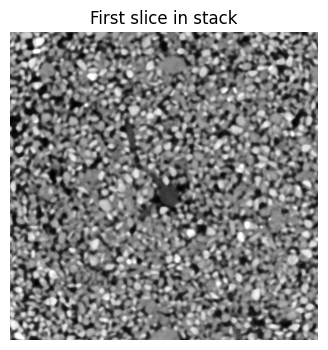

In [ ]:
# ----------------------------
# Load a stack of grayscale slices
# ----------------------------

# Cap the number of slices so we don't accidentally load thousands of files
# min() ensures we never ask for more slices than actually exist on disk
NUM_SLICES = min(MAX_SLICES_TO_LOAD, len(image_files))

# Read each slice from disk and collect them in a Python list
stack_list = []
for fname in image_files[:NUM_SLICES]:          # Iterate over the first NUM_SLICES filenames
    arr = mpimg.imread(os.path.join(IMAGE_DIR, fname))  # Loading the image
    stack_list.append(arr)                       # Add the 2D array to the list

# Stack the list of 2D arrays into a single 3D NumPy array
# axis=0 means slices are stacked along the first dimension, giving shape (num_slices, height, width)
img_stack = np.stack(stack_list, axis=0)
print("Loaded stack shape (slices, H, W):", img_stack.shape)

# Preview the first slice to confirm the data loaded correctly
plt.figure(figsize=(4, 4))
plt.imshow(img_stack[0], cmap="gray")  # img_stack[0] selects the first slice
plt.title("First slice in stack")
plt.axis("off")
plt.show()


First 5 Otsu thresholds: [133.939453125, 133.951171875, 133.939453125, 127.998046875, 127.962890625]


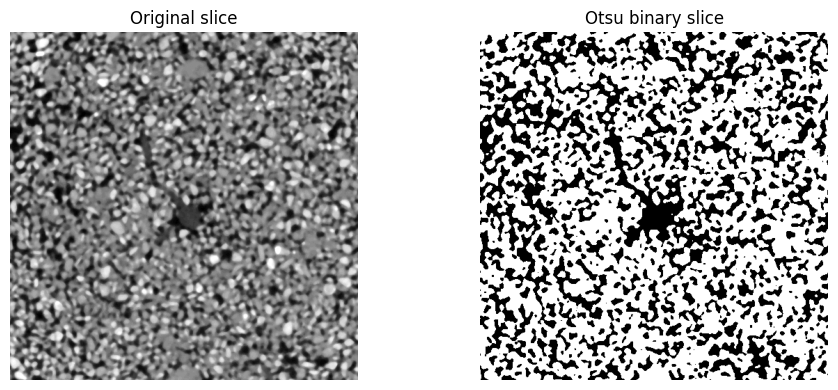

In [14]:
# ----------------------------
# Apply Otsu per slice
# ----------------------------

def otsu_stack_threshold(stack):
    """Apply Otsu threshold independently to each 2D slice in a 3D stack.

    Parameters
    ----------
    stack : np.ndarray
        3D array with shape (num_slices, H, W)

    Returns
    -------
    binary_stack : np.ndarray
        3D uint8 binary masks (0/1) with same shape as input
    thresholds : list[float]
        Otsu threshold value used for each slice
    """

    # Pre-allocate output array for speed and shape consistency
    # np.zeros_like copies shape from stack; dtype uint8 stores compact 0/1 values
    binary_stack = np.zeros_like(stack, dtype=np.uint8)

    # Store one scalar threshold per slice for reporting/inspection
    thresholds = []

    # Loop through slices along the first axis (axis=0)
    for i in range(stack.shape[0]):
        # Compute a single global Otsu threshold for this slice
        t = threshold_otsu(stack[i])
        thresholds.append(float(t))

        # Convert to binary mask using that threshold:
        #   True/False -> cast to uint8 -> 1/0
        binary_stack[i] = (stack[i] > t).astype(np.uint8)

    return binary_stack, thresholds


# Run Otsu thresholding across all loaded slices
binary_stack_otsu, otsu_thresholds = otsu_stack_threshold(img_stack)
print("First 5 Otsu thresholds:", otsu_thresholds[:5])

# Visualise one example slice (original vs segmented)
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].imshow(img_stack[0], cmap="gray")
ax[0].set_title("Original slice")
ax[0].axis("off")

ax[1].imshow(binary_stack_otsu[0], cmap="gray")
ax[1].set_title("Otsu binary slice")
ax[1].axis("off")

plt.tight_layout()
plt.show()


## Step 6 (Optional) - Save thresholded outputs 

Each segmented slice is saved as a PNG image with values 0 (background) and 255 (foreground).

Feel free to provide a different location to save the outputs!

In [15]:
# ----------------------------
# Save Otsu binary slices
# ----------------------------

# Output folder for saved binary masks
# "./" means relative to the notebook's current working directory
OUT_DIR_OTSU = "./filtered_images_otsu_combined"

# Create output directory if it does not already exist
# exist_ok=True prevents errors when rerunning the cell
os.makedirs(OUT_DIR_OTSU, exist_ok=True)

# Loop over all segmented slices and save each as a PNG file
for i in range(binary_stack_otsu.shape[0]):
    # Build output file name with zero-padded index (e.g., slice_000.png)
    out_path = os.path.join(OUT_DIR_OTSU, f"slice_{i:03d}.png")

    # Convert binary mask from 0/1 to 0/255 so it is clearly visible in image viewers
    # Image.fromarray expects standard image intensity range for grayscale PNGs
    Image.fromarray((binary_stack_otsu[i] * 255).astype(np.uint8)).save(out_path)

print("Saved Otsu masks to:", OUT_DIR_OTSU)


Saved Otsu masks to: ./filtered_images_otsu_combined


## Wrap-up

You now have one notebook that combines:

- Basic Otsu thresholding workflow
- Local thresholding comparison (Niblack, Sauvola)
- Multi-slice stack processing and export

## Suggested beginner exercises

1. Change Niblack/Sauvola window size and compare results
2. Increase `MAX_SLICES_TO_LOAD` and check runtime vs quality

## (Optional) Math behind thresholding methods

### Otsu's method

Otsu's method is a global thresholding technique that automatically determines the optimal threshold value 
- By maximizing the between-class variance

It is effective for images with bimodal histograms, where the foreground and background are well separated

$\sigma^2_\omega (t) = \omega_1 (t) \sigma^2_1 (t) + \omega_2 (t) \sigma^2_2 (t)$

Where:

- $\omega_1 (t)$ and $\omega_2 (t)$ are the probabilities of the two classes separated by the threshold t
- $\sigma^2_1 (t)$ and $\sigma^2_2 (t)$ are the variances of the two classes

### Niblack's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood around the pixel. 

It is effective for images with varying contrast.

$T(x,y) = m(x,y) + k \cdot s(x,y)$

Where:

- $T(x,y)$ is the threshold for the pixel at coordinates (x, y)
- $m(x,y)$ is the mean of the local neighborhood around the pixel
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold


### Sauvola's method

Calculates the threshold for each pixel based on the mean and standard deviation of a local neighborhood, similar to Niblack's method
- But includes a parameter to control the influence of the standard deviation

It is effective for images with varying contrast and noise.

$T(x,y) = m(x,y) \cdot \left(1 + k \cdot \left(\frac{s(x,y)}{R} - 1\right)\right)$

Where:
- $T(x,y)$ is the threshold for the pixel at coordinates (x, y)
- $m(x,y)$ is the mean of the local neighborhood around the pixel
- $s(x,y)$ is the standard deviation of the local neighborhood around the pixel
- $k$ is a user-defined parameter that controls the influence of the standard deviation on the threshold
- $R$ is the dynamic range of the standard deviation (typically set to 128 for 8-bit images)

## Helpful Resources

No worries if the details of thresholding methods are not clear yet. We recommend that you check out the following resources to learn more:

- Introduction to thresholding: https://scikit-image.org/docs/stable/auto_examples/applications/plot_thresholding_guide.html#sphx-glr-auto-examples-applications-plot-thresholding-guide-py
- Otsu thresholding: https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_thresholding.html 
- Niblack and Sauvola thresholding: https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_niblack_sauvola.html

scikit-image website (https://scikit-image.org/) has great short tutorials on simple image processing and segmentation methods.

Happy learning!